In [20]:
import os
import re
import pandas as pd
import matplotlib.colors as mcolors
import colorsys
import numpy as np
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing import event_accumulator


In [21]:
def collect_runs(log_dir):
    rows = []

    for root, _, files in os.walk(log_dir):
        if not any("events.out.tfevents" in f for f in files):
            continue

        ea = event_accumulator.EventAccumulator(
            root,
            size_guidance={"scalars": 0}
        )
        ea.Reload()

        tags = ea.Tags().get("scalars", [])
        if not tags:
            continue

        run_name = os.path.basename(root)
        tokens = run_name.split("_")

        if len(tokens) != 4:
            print(f"Skipping unrecognized run name: {run_name}")
            continue

        dataset, is_sam, rho, pruning_ratio = tokens

        is_sam = is_sam.lower() == "true"
        rho = None if rho == "None" else float(rho)
        pruning_ratio = float(pruning_ratio)

        for tag in tags:
            eig_match = re.match(r"eigval_(\d+)/test", tag)

            for e in ea.Scalars(tag):
                rows.append({
                    "dataset": dataset,
                    "is_sam": is_sam,
                    "rho": rho,
                    "pruning_ratio": pruning_ratio,
                    "metric": tag,
                    "metric_group": (
                        "eigval" if eig_match else tag.split("/")[0]
                    ),
                    "eig_idx": int(eig_match.group(1)) if eig_match else None,
                    "split": tag.split("/")[-1] if "/" in tag else None,
                    "step": e.step,
                    "value": e.value,
                })

    return rows


In [ ]:
model_dataset_2_parameters = {
    ("resnet", "CIFAR10"): {
        "SPARSE_LOG_DIR": "./src/tensorboard/logs/runs_sparse/ResNet18_test",
        "DENSE_LOG_DIR": "./src/tensorboard/logs/CIFAR10/resnet_cifar10_dense",
        "ylims_loss_sam": [(0, 100), (0, 5)],
        "ylims_acc": (0.4, 1)
    },
    ("vgg", "CIFAR10"): {
        "SPARSE_LOG_DIR": "./src/tensorboard/logs/runs_sparse/vgg16_bn_test",
        "DENSE_LOG_DIR": None,
        "ylims_loss_sam": [(0, 12), (0, 12)],
        "ylims_acc": (0.4, 1)
    },
    ("resnet", "CIFAR100"): {
        "SPARSE_LOG_DIR": "./src/tensorboard/logs/CIFAR100/resnet18",
        "DENSE_LOG_DIR": None,
        "ylims_loss_sam": [None, None],
        "ylims_acc": None
    },
    ("vgg", "CIFAR100"): {
        "SPARSE_LOG_DIR": "./src/tensorboard/logs/CIFAR100/vgg16",
        "DENSE_LOG_DIR": None,
        "ylims_loss_sam": [(-2, 20), (-2, 20)],
        "ylims_acc": None
    },
    ("wide_resnet", "CIFAR100"): {
        "SPARSE_LOG_DIR": "./src/tensorboard/logs/CIFAR100/wide_resnet",
        "DENSE_LOG_DIR": None,
        "ylims_loss_sam": [None, None],
        "ylims_acc": None
    },
}

In [23]:
#model_name = "resnet"
model_name = "vgg"
#model_name = "wide_resnet"
dataset_name = "CIFAR10"
#dataset_name = "CIFAR100"

SPARSE_LOG_DIR = model_dataset_2_parameters[(model_name, dataset_name)]["SPARSE_LOG_DIR"]
DENSE_LOG_DIR = model_dataset_2_parameters[(model_name, dataset_name)]["DENSE_LOG_DIR"]
ylims_loss_sam = model_dataset_2_parameters[(model_name, dataset_name)]["ylims_loss_sam"]
ylims_acc = model_dataset_2_parameters[(model_name, dataset_name)]["ylims_acc"]

rows = []
rows.extend(collect_runs(SPARSE_LOG_DIR))
if DENSE_LOG_DIR is not None:
    rows.extend(collect_runs(DENSE_LOG_DIR))

df = pd.DataFrame(rows)

print(f"Loaded {len(df)} rows")
df.head()

Loaded 31716 rows


,dataset,is_sam,rho,pruning_ratio,metric,metric_group,eig_idx,split,step,value
0,cifar10,True,None,0.0,Loss/train,Loss,NaN,train,1,2.102880
1,cifar10,True,None,0.0,Loss/train,Loss,NaN,train,2,1.977214
2,cifar10,True,None,0.0,Loss/train,Loss,NaN,train,3,1.916405
3,cifar10,True,None,0.0,Loss/train,Loss,NaN,train,4,1.865391
4,cifar10,True,None,0.0,Loss/train,Loss,NaN,train,5,1.797657


In [24]:
metrics = df["metric"].unique().tolist()
metrics.sort()
metrics

['Accuracy/test',
 'Accuracy/train',
 'Loss/test',
 'Loss/train',
 'SAM Loss/test',
 'SAM Loss/train',
 'eigval_0/test',
 'eigval_1/test',
 'eigval_2/test',
 'eigval_3/test',
 'eigval_4/test',
 'eigval_5/test',
 'eigval_6/test',
 'eigval_7/test',
 'eigval_8/test',
 'eigval_9/test',
 'sparsity',
 'trace/test',
 'trace_per_param/test']

In [25]:
pruning_ratios = df["pruning_ratio"].unique().tolist()
pruning_ratios.sort()
pruning_ratios

[0.0, 0.5, 0.7, 0.9, 0.95]

In [26]:
import colorsys
import matplotlib.colors as mcolors

def make_tonal_palette(
    base_hue,
    n,
    l_max=0.78,
    l_min=0.28,
    s=0.85,
    hue_span=0.06,
    hue_direction=0  # 0: symmetric, -1: toward red, +1: toward yellow
):
    """
    Discrete, high-contrast tonal palette.
    Colors get darker and shift hue in a controlled direction.
    """
    colors = []

    for i in range(n):
        t = i / (n - 1)

        # darker with pruning
        l = l_max - t * (l_max - l_min)

        # directional hue shift
        if hue_direction == 0:
            h = (base_hue + (t - 0.5) * hue_span) % 1.0
        else:
            h = (base_hue + hue_direction * t * hue_span) % 1.0

        colors.append(colorsys.hls_to_rgb(h, l, s))

    return colors


BASE_COLORS = {
    True: "#FF7F0E",   # orange (SAM)
    False: "#1F77B4",  # blue (SGD)
}

N_PRUNING = 5

PALETTE = {
    "SGD": make_tonal_palette(
        base_hue=colorsys.rgb_to_hls(*mcolors.to_rgb(BASE_COLORS[False]))[0],
        n=N_PRUNING,
        l_max=0.75,
        l_min=0.35,
        s=0.85,
        hue_span=0.06,
        hue_direction=0,   # symmetric (blue works well)
    ),
    "SAM": make_tonal_palette(
        base_hue=colorsys.rgb_to_hls(*mcolors.to_rgb(BASE_COLORS[True]))[0],
        n=N_PRUNING,
        l_max=0.62,        # cap brightness
        l_min=0.28,
        s=0.95,            # keep vivid → avoid brown
        hue_span=0.12,     # strong red shift
        hue_direction=-1,  # ONLY toward red
    )
}

pruning_ratios_sorted = sorted(pruning_ratios)

COLOR_MAP = {
    sam: {
        p: PALETTE["SAM" if sam else "SGD"][i]
        for i, p in enumerate(pruning_ratios_sorted)
    }
    for sam in [True, False]
}


Accuracy/test


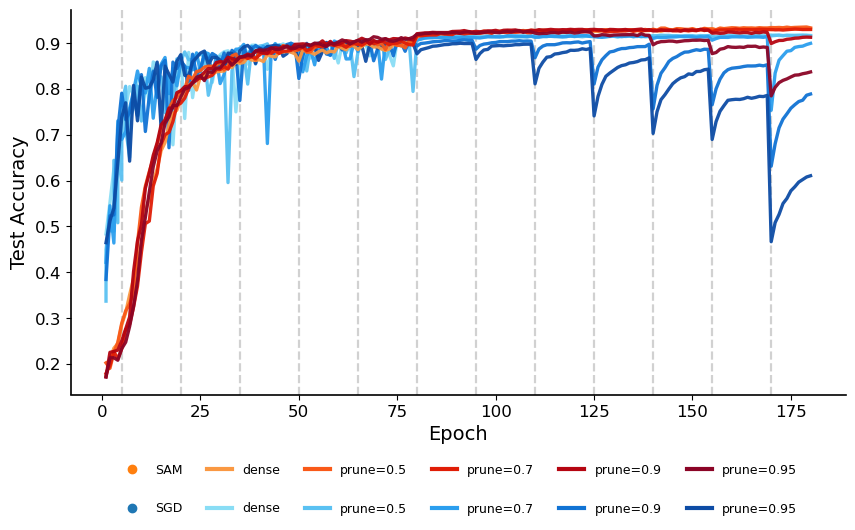

Accuracy/train


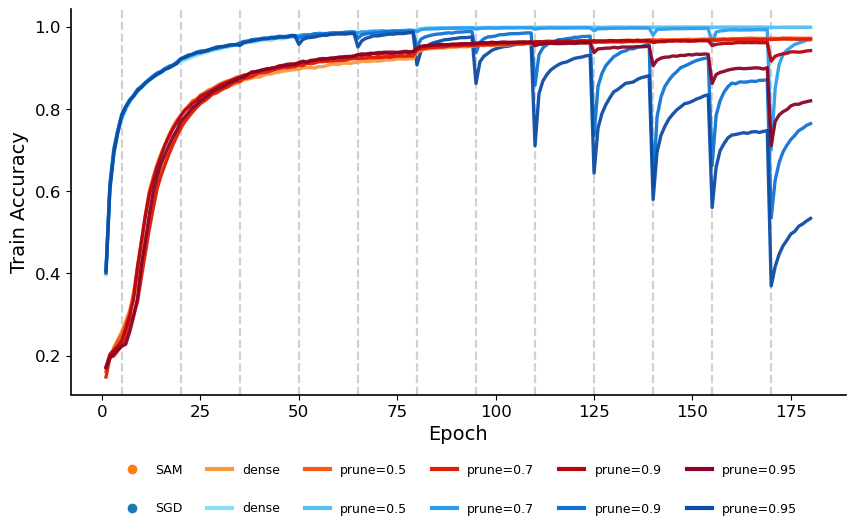

Loss/test


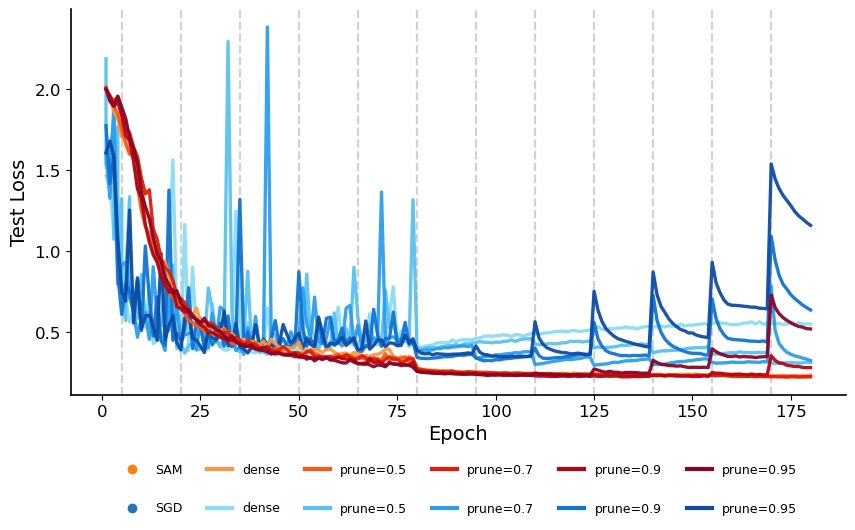

Loss/train


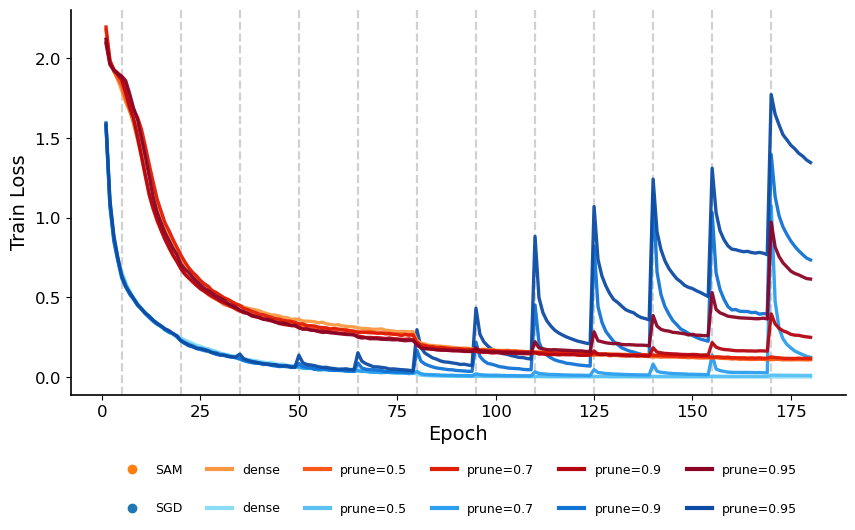

SAM Loss/test


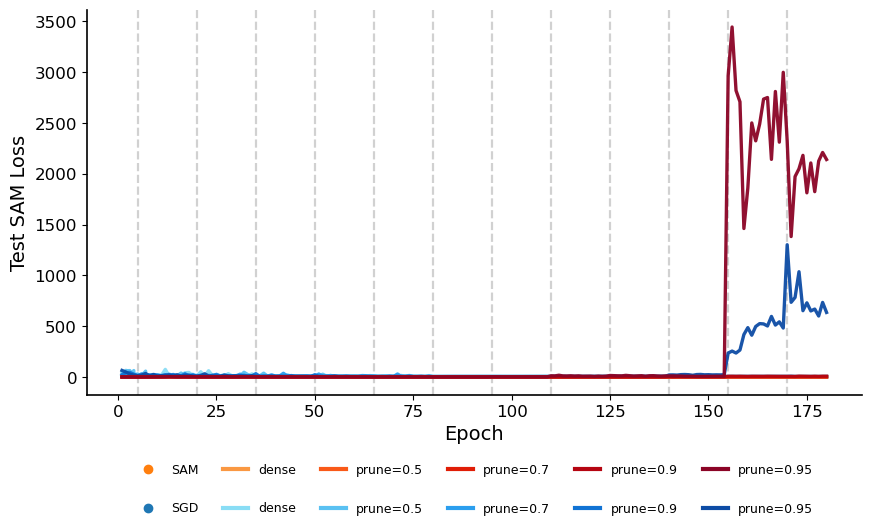

SAM Loss/train


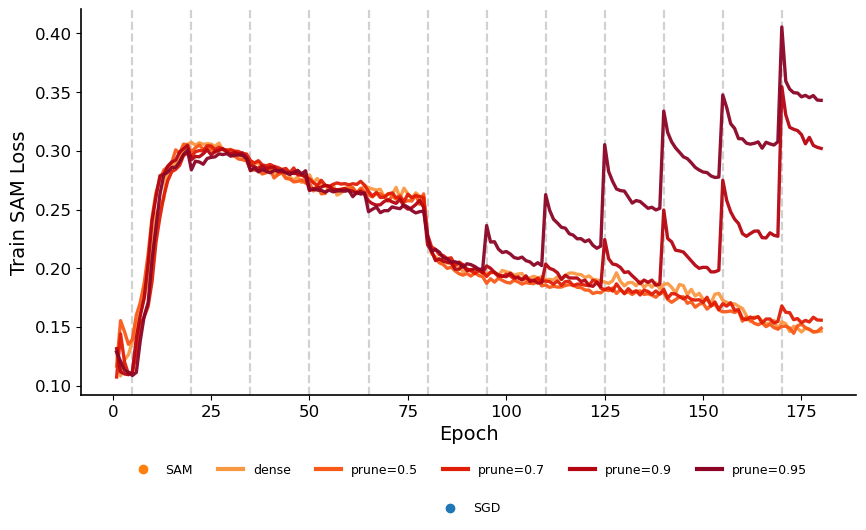

eigval_0/test


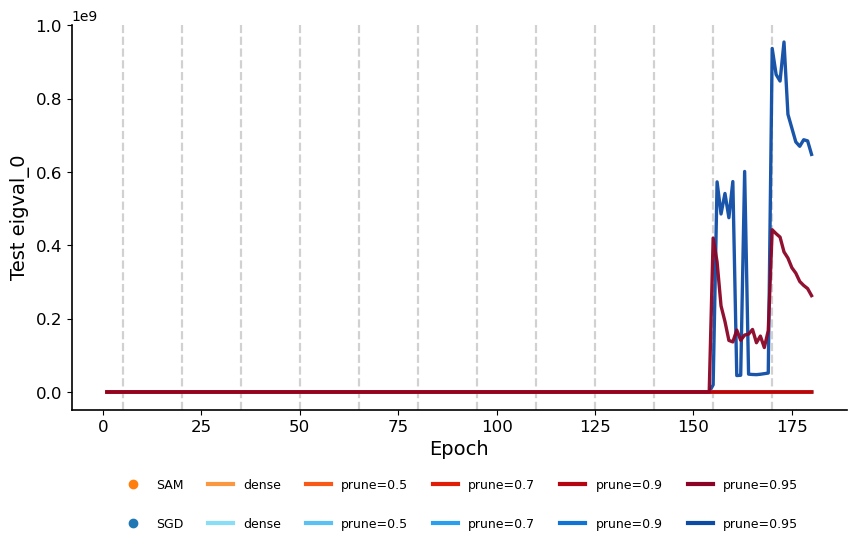

eigval_1/test


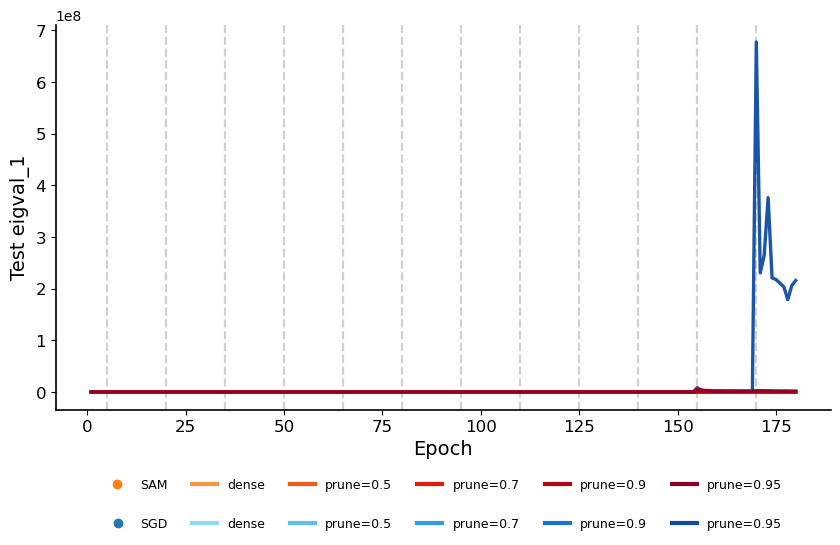

eigval_2/test


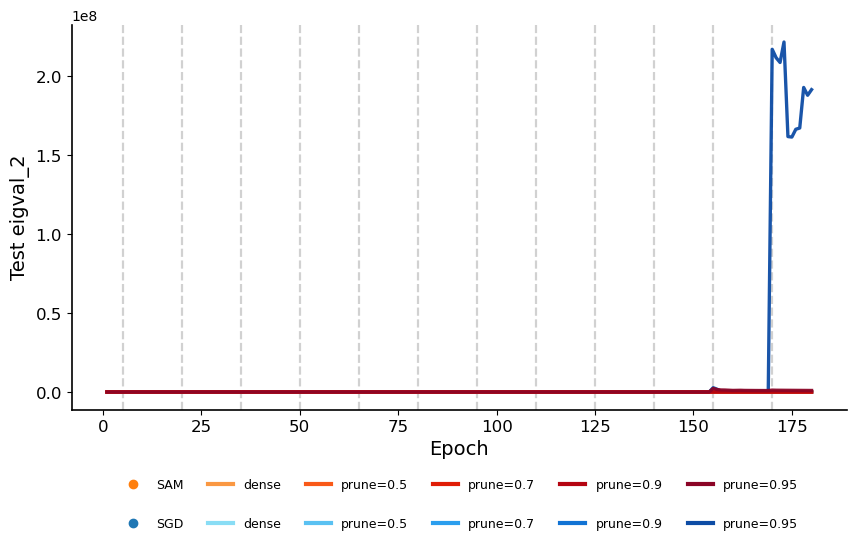

eigval_3/test


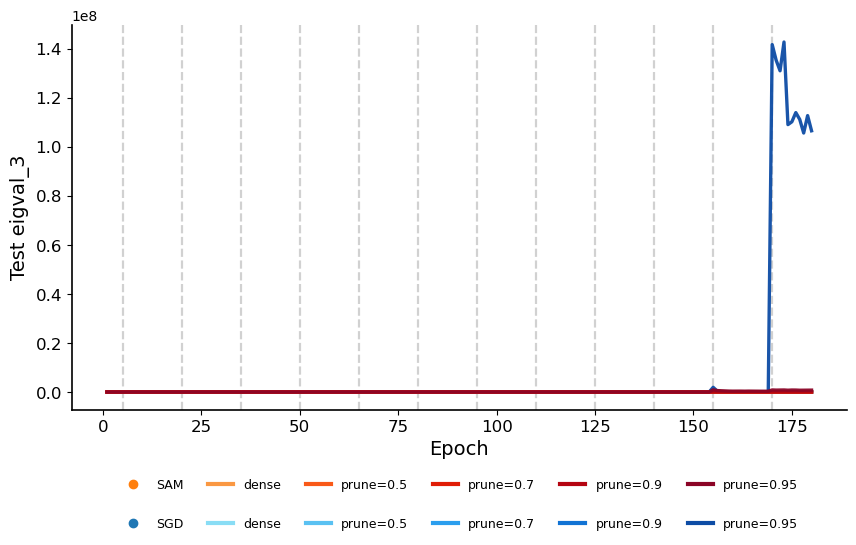

eigval_4/test


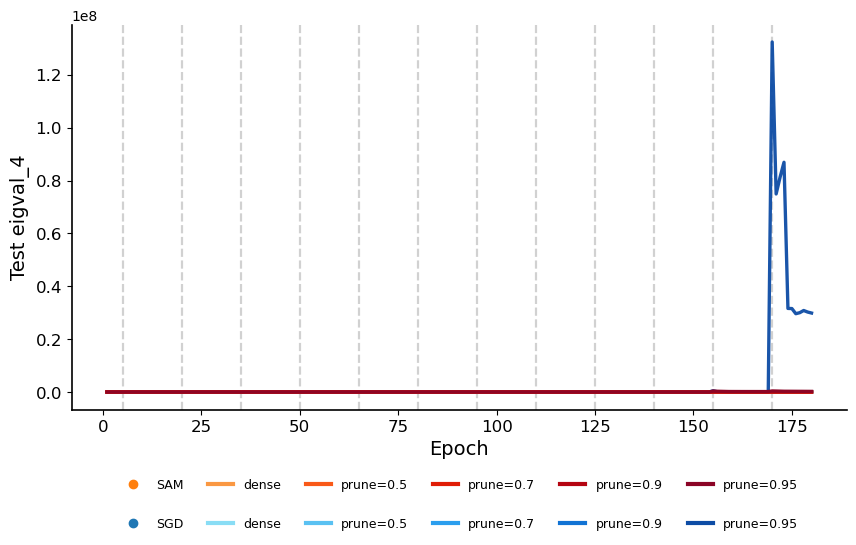

eigval_5/test


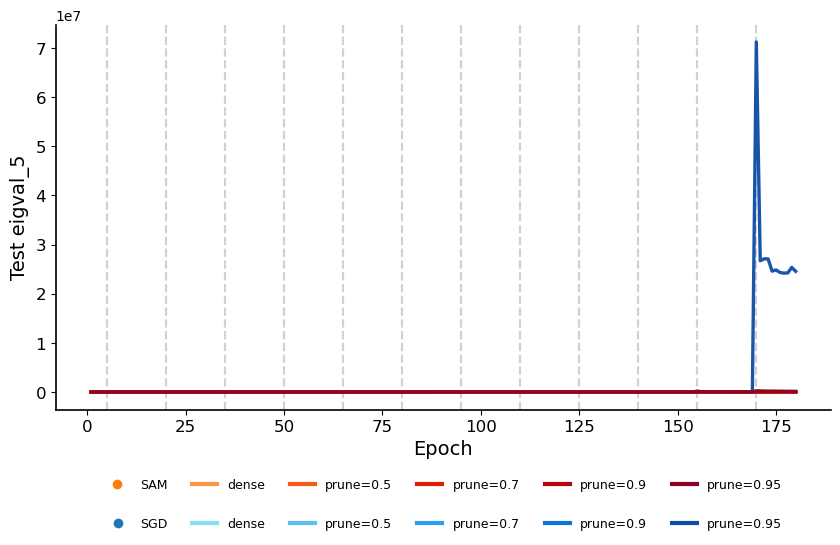

eigval_6/test


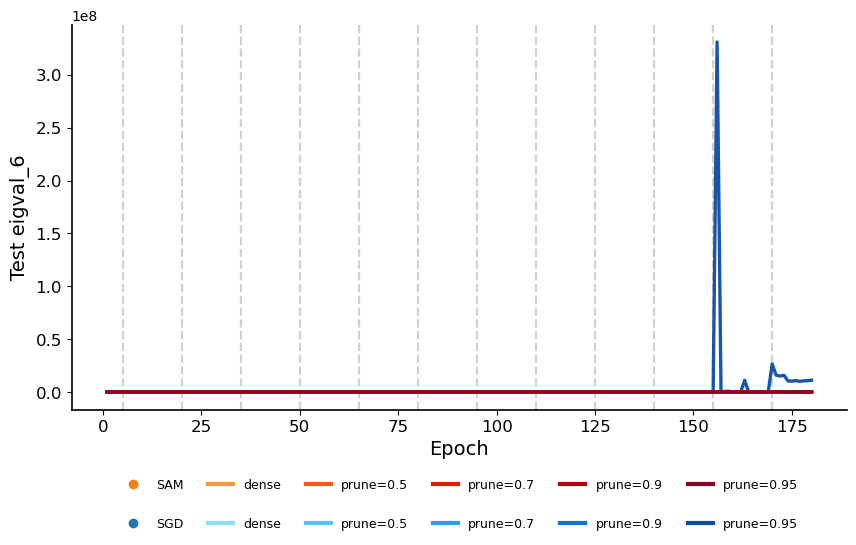

eigval_7/test


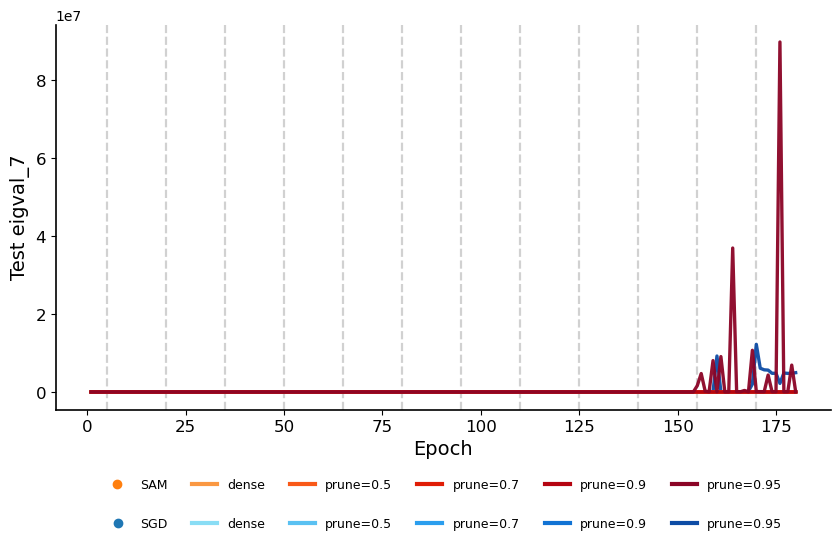

eigval_8/test


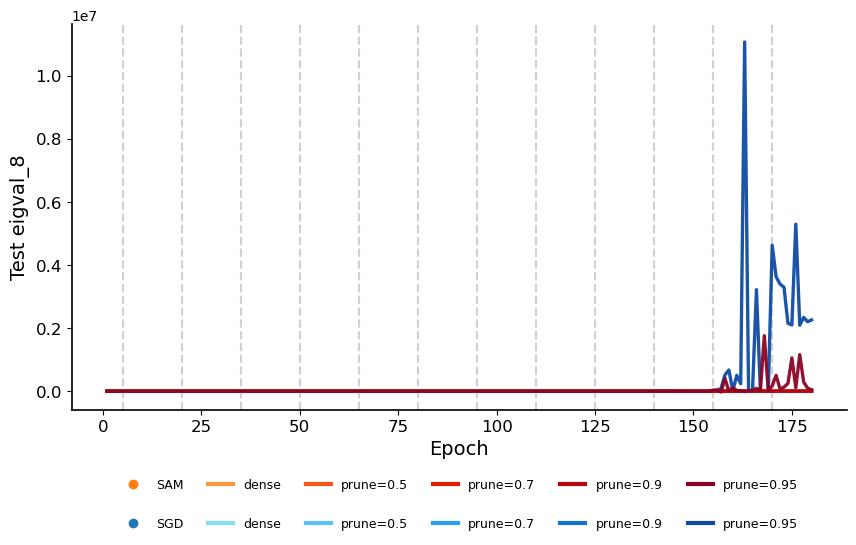

eigval_9/test


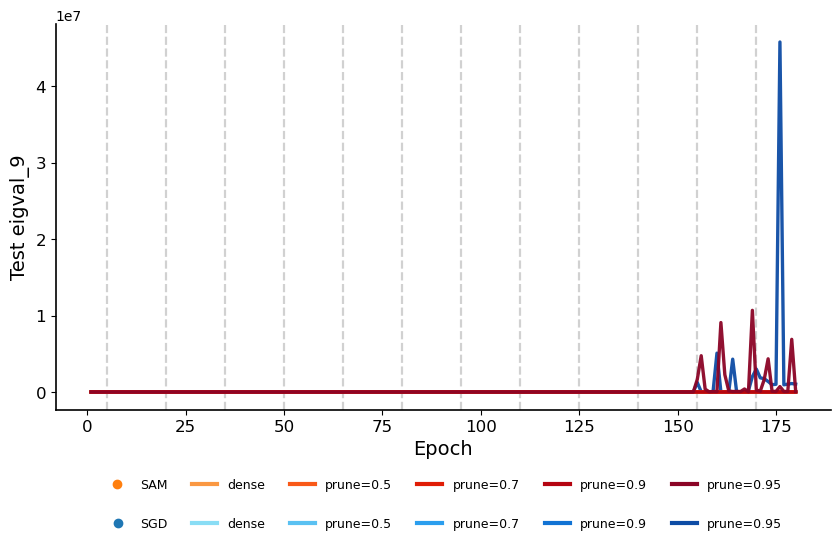

sparsity


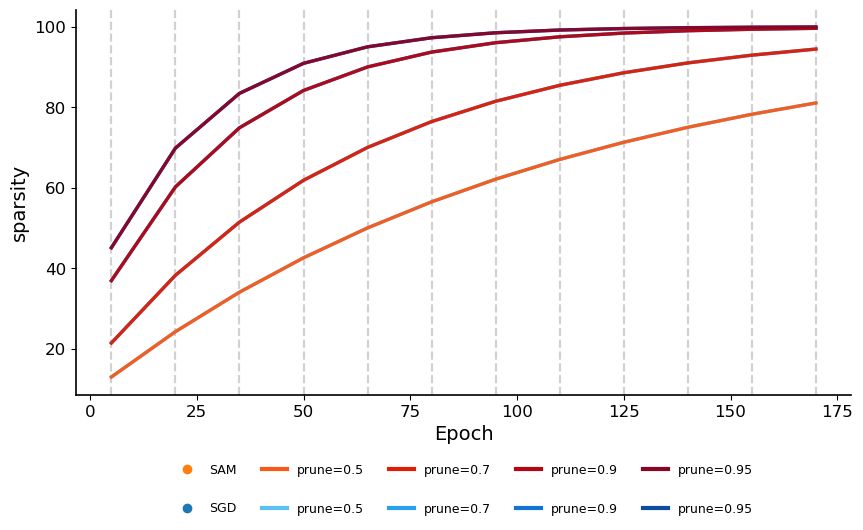

trace/test


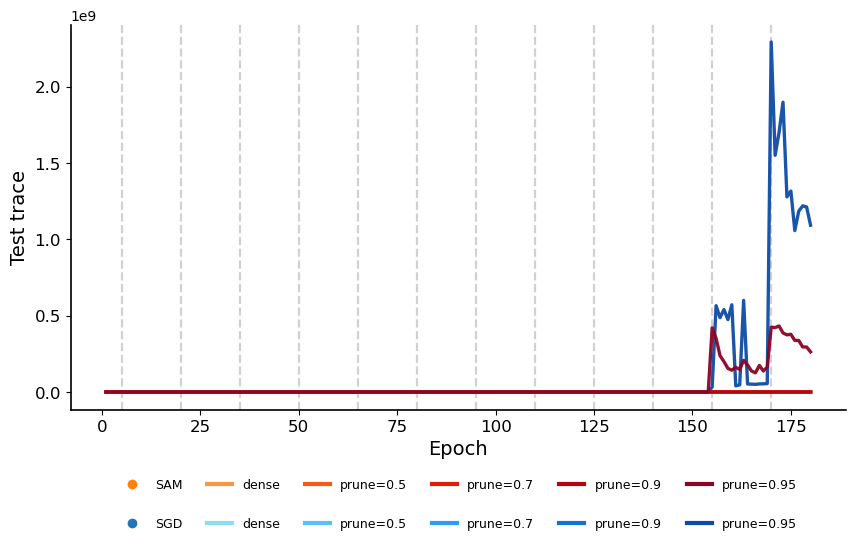

trace_per_param/test


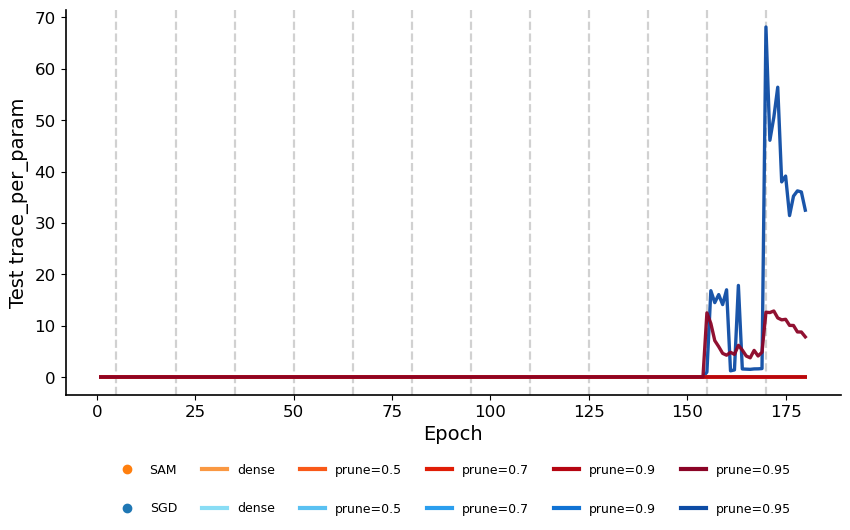

In [27]:
# -----------------------------
# Plotting
# -----------------------------
for metric in metrics:
    fig, ax = plt.subplots(figsize=(10, 5))

    # ---- Separate legend handles for SAM and SGD ----
    legend_lines_sam = []
    legend_labels_sam = []

    legend_lines_sgd = []
    legend_labels_sgd = []

    # ---- Plot curves ----
    for sam in [False, True]:
        for pruning_ratio in pruning_ratios_sorted:

            df_plot = df[
                (df["is_sam"] == sam) &
                (df["pruning_ratio"] == pruning_ratio) &
                (df["metric"] == metric)
            ].sort_values("step")

            if df_plot.empty:
                continue

            ax.plot(
                df_plot["step"],
                df_plot["value"],
                color=COLOR_MAP[sam][pruning_ratio],
                linewidth=2.4,
                alpha=0.95,
                zorder=3
            )

            # Add to correct legend list
            label = f"prune={pruning_ratio}" if pruning_ratio != 0 else "dense" 
            handle = plt.Line2D([0], [0], color=COLOR_MAP[sam][pruning_ratio], linewidth=3)
            if sam:
                legend_lines_sam.append(handle)
                legend_labels_sam.append(label)
            else:
                legend_lines_sgd.append(handle)
                legend_labels_sgd.append(label)

    # ---- Pruning steps ----
    max_step = df[df["metric"] == metric]["step"].max()
    for step in range(5, int(max_step) + 1, 15):
        ax.axvline(step, color="black", linewidth=1.6, linestyle="dashed", alpha=0.18, zorder=1)

    # ---- Axes styling ----
    #ax.set_title(metric, fontsize=16, pad=30)
    print(metric)
    ax.set_xlabel("Epoch", fontsize=14)
    metric_name = f"{metric.split("/")[1].capitalize()} {metric.split("/")[0]}" if "/" in metric else metric
    ax.set_ylabel(metric_name, fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    #ax.grid(True, axis="y", alpha=0.3)

    # ---- Add dummy markers for SAM/SGD legend ----
    dummy_sam = plt.Line2D([0], [0], color=BASE_COLORS[True], marker='o', linestyle='', markersize=6)
    dummy_sgd = plt.Line2D([0], [0], color=BASE_COLORS[False], marker='o', linestyle='', markersize=6)

    # ---- Legend: SAM (top row) ----
    legend1 = ax.legend(
        [dummy_sam] + legend_lines_sam,
        ["SAM"] + legend_labels_sam,
        ncol=len([dummy_sam] + legend_lines_sam),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        frameon=False,
        fontsize=9
    )
    ax.add_artist(legend1)

    # ---- Legend: SGD (bottom row) ----
    ax.legend(
        [dummy_sgd] + legend_lines_sgd,
        ["SGD"] + legend_labels_sgd,
        ncol=len([dummy_sgd] + legend_lines_sgd),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        frameon=False,
        fontsize=9
    )

    plt.show()


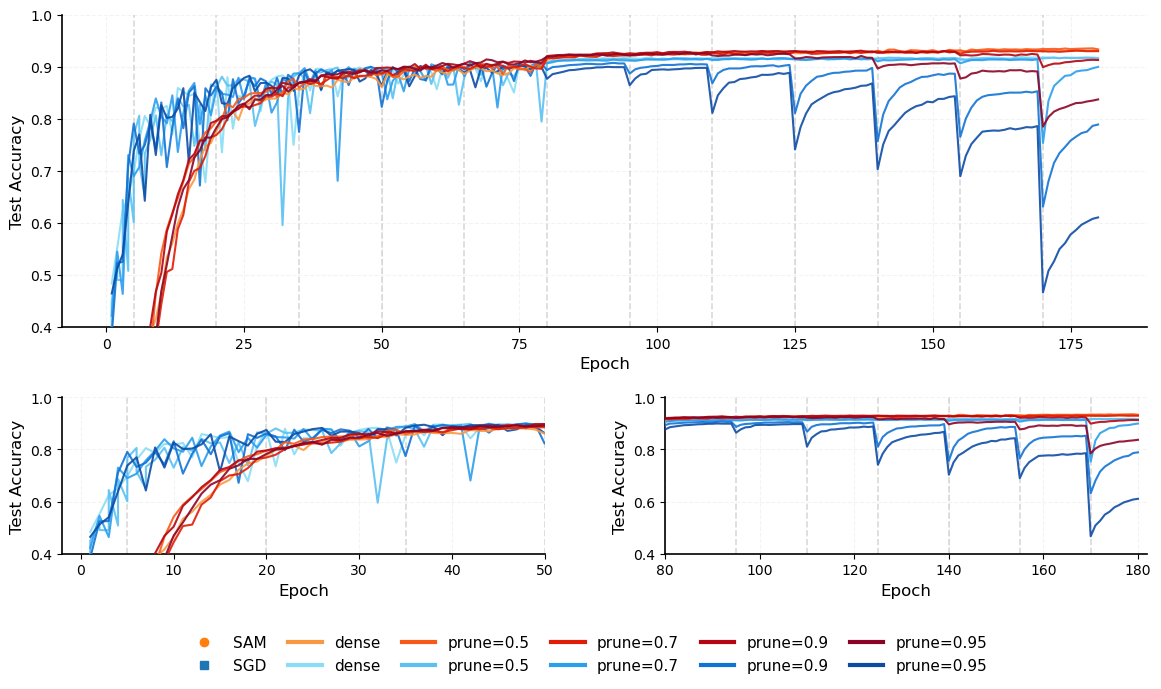

In [28]:
# -----------------------------
# Create figure and axes
# -----------------------------
fig = plt.figure(figsize=(14, 7))

# Grid layout: 2 rows, top large plot, bottom row two smaller plots
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.25)
ax_top = fig.add_subplot(gs[0, :])      # Full plot on top
ax_bottom_left = fig.add_subplot(gs[1, 0])   # Zoomed left
ax_bottom_right = fig.add_subplot(gs[1, 1])  # Zoomed right

axes = [ax_top, ax_bottom_left, ax_bottom_right]
xlims = [None, (-2, 50), (80, 182)]  # None means full range

# -----------------------------
# Plotting function
# -----------------------------
def plot_curves(ax, xlim=None):
    legend_lines_sam = []
    legend_labels_sam = []
    legend_lines_sgd = []
    legend_labels_sgd = []

    for sam in [False, True]:
        for pruning_ratio in pruning_ratios_sorted:
            df_plot = df[
                (df["is_sam"] == sam) &
                (df["pruning_ratio"] == pruning_ratio) &
                (df["metric"] == metric)
            ].sort_values("step")

            if df_plot.empty:
                continue

            lw = 1.5 #+ 2.0 * (1 - pruning_ratio)  # optional: thicker for less pruning
            ax.plot(
                df_plot["step"],
                df_plot["value"],
                color=COLOR_MAP[sam][pruning_ratio],
                linewidth=lw,
                alpha=0.9,
                zorder=3
            )

            # Add to legend
            label = "dense" if pruning_ratio == 0 else f"prune={pruning_ratio}"
            handle = plt.Line2D([0], [0], color=COLOR_MAP[sam][pruning_ratio], linewidth=3)
            if sam:
                legend_lines_sam.append(handle)
                legend_labels_sam.append(label)
            else:
                legend_lines_sgd.append(handle)
                legend_labels_sgd.append(label)

    # Vertical pruning step lines
    max_step = df[df["metric"] == metric]["step"].max()
    for step in range(5, int(max_step)+1, 15):
        ax.axvline(step, color="black", linewidth=1.2, linestyle="dashed", alpha=0.15, zorder=1)

    # Axes labels
    ax.set_xlabel("Epoch", fontsize=12)
    metric_name = f"{metric.split('/')[1].capitalize()} {metric.split('/')[0]}" if "/" in metric else metric
    ax.set_ylabel(metric_name, fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(True, alpha=0.15, linestyle='--', linewidth=0.8)

    if xlim:
        ax.set_xlim(xlim)
    ax.set_ylim(ylims_acc)

    # -----------------------------
    # Add a single legend at the bottom
    # -----------------------------

    # -----------------------------
# Single legend with two rows
# -----------------------------

legend_lines_sam = [plt.Line2D([0], [0], color=COLOR_MAP[True][pr], linewidth=3) for pr in pruning_ratios_sorted]
legend_lines_sgd = [plt.Line2D([0], [0], color=COLOR_MAP[False][pr], linewidth=3) for pr in pruning_ratios_sorted]

legend_labels = ["dense" if r == 0 else f"prune={r}" for r in pruning_ratios_sorted]

dummy_sam = plt.Line2D([0], [0], color=BASE_COLORS[True], marker='o',
                       linestyle='', markersize=6)
dummy_sgd = plt.Line2D([0], [0], color=BASE_COLORS[False], marker='s',
                       linestyle='', markersize=6)

# Interleave handles column-wise
handles = []
labels = []

# First column (optimizer label)
handles.extend([dummy_sam, dummy_sgd])
labels.extend(["SAM", "SGD"])

# Remaining columns (pruning ratios)
for h_sam, h_sgd, lab in zip(legend_lines_sam, legend_lines_sgd, legend_labels):
    handles.extend([h_sam, h_sgd])
    labels.extend([lab, lab])

fig.legend(
    handles=handles,
    labels=labels,
    ncol=len(legend_labels) + 1,
    loc="lower center",
    frameon=False,
    fontsize=11,
    handlelength=2.2,
    columnspacing=1.4,
    bbox_to_anchor=(0.5, -0.08)
)


# -----------------------------
# Plot metric
# -----------------------------
metric = "Accuracy/test"

for ax, xlim in zip(axes, xlims):
    plot_curves(ax, xlim=xlim)

plt.savefig(f"figures/test_acc_{model_name}_{dataset_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()


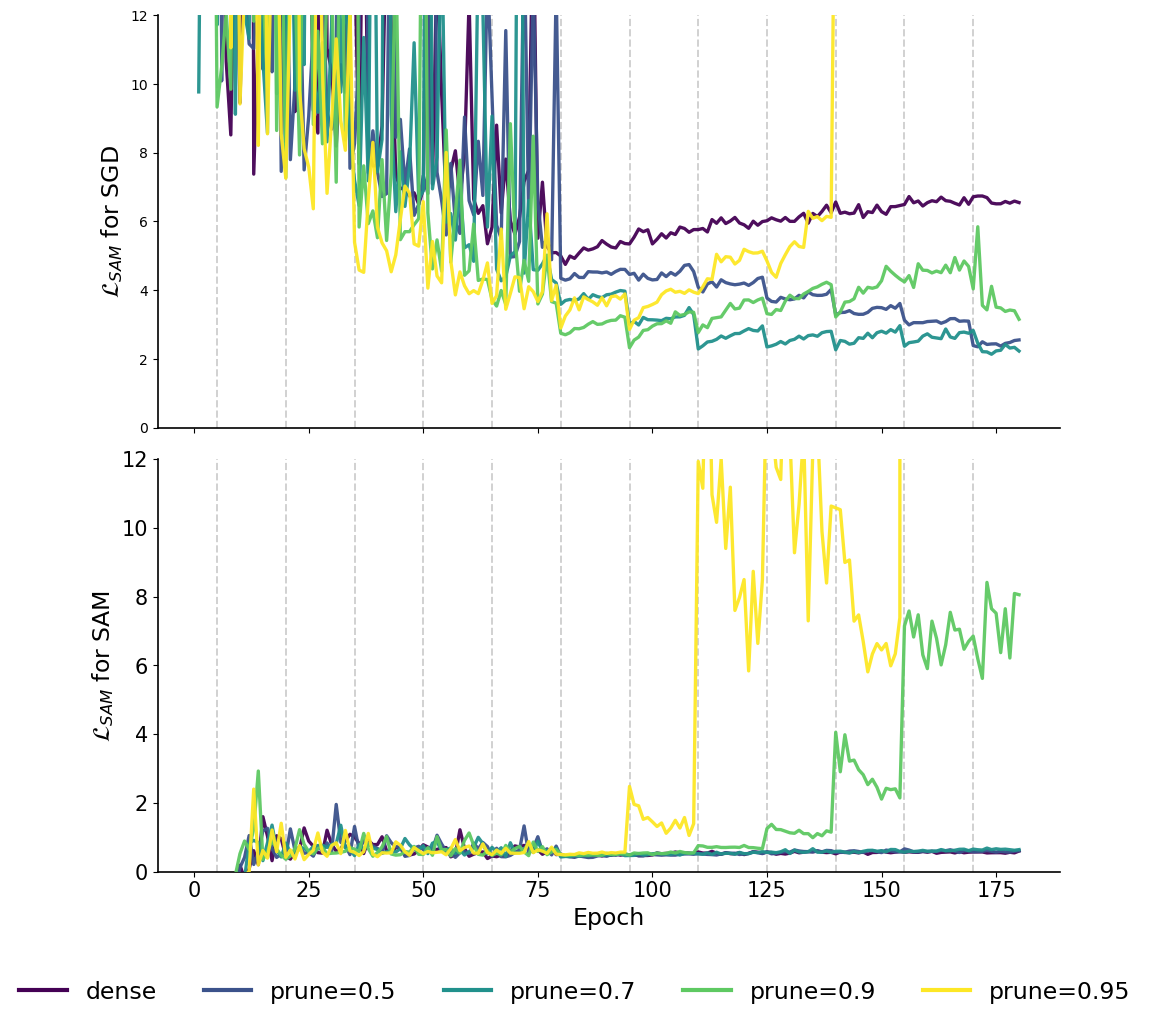

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# Configuration
# -----------------------------
metric = "SAM Loss/test"
pruning_ratios_sorted = sorted(pruning_ratios)

# Smooth, gradual colormap for pruning ratios
COLORS = [
    cm.viridis(i / (len(pruning_ratios_sorted) - 1))
    for i in range(len(pruning_ratios_sorted))
]

# -----------------------------
# Create figure (vertical layout)
# -----------------------------
fig, axes = plt.subplots(
    2, 1, figsize=(10, 10), sharex=True  # stacked vertically
)

ax_sgd, ax_sam = axes
AX_MAP = {False: ax_sgd, True: ax_sam}

legend_lines = []
legend_labels = []

# -----------------------------
# Plot curves
# -----------------------------
for sam in [False, True]:
    ax = AX_MAP[sam]

    for color, pruning_ratio in zip(COLORS, pruning_ratios_sorted):
        df_plot = df[
            (df["is_sam"] == sam) &
            (df["pruning_ratio"] == pruning_ratio) &
            (df["metric"] == metric)
        ].sort_values("step").reset_index()

        if df_plot.empty:
            continue

        # Subtract base loss
        df_loss = df[
            (df["is_sam"] == sam) &
            (df["pruning_ratio"] == pruning_ratio) &
            (df["metric"] == "Loss/test")
        ].sort_values("step").reset_index()
        df_plot["value_diff"] = df_plot["value"] - df_loss["value"]

        ax.plot(
            df_plot["step"],
            df_plot["value_diff"],
            color=color,
            linewidth=2.4,
            alpha=0.95,
            zorder=3
        )

        # Build legend once (shared)
        if sam is False:
            label = "dense" if pruning_ratio == 0 else f"prune={pruning_ratio}"
            legend_lines.append(
                plt.Line2D([0], [0], color=color, linewidth=3)
            )
            legend_labels.append(label)

    # Pruning step markers
    for step in range(5, 181, 15):
        ax.axvline(
            step,
            color="black",
            linewidth=1.4,
            linestyle="dashed",
            alpha=0.18,
            zorder=1
        )

    # Axis styling
    if sam:
        ax.set_xlabel("Epoch", fontsize=17)
        ax.tick_params(axis="both", labelsize=15)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    title = "SGD (SAM = False)" if not sam else "SAM (SAM = True)"
    #ax.set_title(title, fontsize=14)

# Shared y-axis
ax_sgd.set_ylabel(r"$\mathcal{L}_{SAM}$ for SGD", fontsize=17)
ax_sgd.set_ylim(ylims_loss_sam[0])
ax_sam.set_ylabel(r"$\mathcal{L}_{SAM}$ for SAM", fontsize=17)
ax_sam.set_ylim(ylims_loss_sam[1])

# -----------------------------
# Shared legend (bottom)
# -----------------------------
fig.legend(
    handles=legend_lines,
    labels=legend_labels,
    loc="lower center",
    ncol=len(legend_lines),
    frameon=False,
    fontsize=17,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save figure
plt.savefig(f"figures/sam_loss_{model_name}_{dataset_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()
